In [835]:
import numpy as np
import matplotlib.pyplot as plt 
import copy

In [836]:
#Cas n°1 : Ici l'économie se déroule dans un environnement libre et stable, les agents sont rationnels, l'information est parfaite et il n'y a pas d'impact ni d'influence d'acteurs exterieurs (état etc..)
#il n'y a donc pas non plus de régulation ni d'intervention étatique et ni de bulles speculatives

In [867]:
def passage(matrice, etat):
    """ en fontion d'un état, cette fonction définit aléatoirement le prochain état du marché """
    nvetat = 0
    k = np.random.uniform()
    if k <matrice[etat][0]:
        nvetat =0
    else:
        if k < matrice[etat][0] + matrice[etat][1] and k >= matrice[etat][0]:   
            nvetat = 1
        else:
            nvetat = 2
    return nvetat

#on definit etat 0 = crise, etat 1 = stable, etat 2 = croissance


def probapopulation(etat, vecteurpopulation):
    """Fonction qui modifie l'opinion de la population en fonction de l'état du marché"""
    vecteur = []
    if etat == 0:
        return vecteurpopulation * 0.9
    if etat == 1:
        return vecteurpopulation
    if etat == 2: 
        for e in vecteurpopulation:
            if e*1.1<1:
               vecteur.append(e*1.1)
            else:
                vecteur.append(1)
        return np.array(vecteur)


def prop_investisseurs(etat, vecteurpopulation):
    """fonction qui determine le nombre d'investisseurs en fonction de l'état du marché"""
    if etat == 2:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.4])
    if etat == 1:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e > 0.5])
    if etat == 0:
        vecteur_investisseurs = np.array([e for e in vecteurpopulation if e < 0.4])
    
    return vecteur_investisseurs



def calculer_indice(vecteurindice, vecteur_investisseurs, etat):
    for i in range(len(vecteurindice)):
        res = 0  

        if etat == 0:
            for inv in vecteur_investisseurs:
                res -= np.random.normal(0.002, 0.00001)

        elif etat == 2:
            for inv in vecteur_investisseurs:
                res += np.random.normal(0.002, 0.00001)

        else:
            for inv in vecteur_investisseurs:
                res += np.random.normal(0, 0.00001)

        vecteurindice[i] += res

        if vecteurindice[i] < 0.01:
            vecteurindice[i] = 0.01

    return np.mean(vecteurindice)

def probamatrice(matrice, etat, indice1, indice0, epsilon):
    '''Cette fonction modifie la matrice de transition en fonction de l'évolution de l'indice et de l'état'''

    variation = (indice1 - indice0) / max(indice0, 0.01)
    sensibilité = epsilon

    ligne = matrice[etat].copy()  # on copie la ligne pour éviter de modifier la matrice pendant les calculs    

    if abs(variation) < 0.0001:
        return matrice

    if indice1 < 0.01:
        ligne[0] = min(0.99, ligne[0] + sensibilité)
        ligne[2] = max(0, ligne[2] - sensibilité)
        ligne[1] = 1 - ligne[0] - ligne[2]
    else:
        transfert_max = 0.1

        if variation > 0:
            transfert = min(ligne[0],               #on choisit le min de la proba de passer en crise, la sensibilité * la variation et un transfert max pour éviter des changements trop brusques
                            abs(sensibilité * variation),           #les min garantissent aussi qu'on ne retire pas plus que la proba qu'on passe en crise
                            transfert_max)  

            ligne[0] -= transfert
            ligne[1] += transfert / 2
            ligne[2] += transfert / 2

        elif variation < 0:
            transfert = min(ligne[2],              #on choisit le min de la proba de passer en croissance, la sensibilité * la variation et un transfert max pour éviter des changements trop brusques
                            abs(sensibilité * variation),       
                            transfert_max)

            ligne[2] -= transfert
            ligne[1] += transfert / 2
            ligne[0] += transfert / 2

    ligne = [max(0, x) for x in ligne]       #on s'assure que les proba restent positives

    s = sum(ligne)
    if s == 0:
        ligne = [1/3, 1/3, 1/3]         #si la somme est nulle (ce qui ne devrait pas arriver), on remet des proba égales
    else:
        ligne = [x / s for x in ligne]      #on normalise pour que la somme soit 1

    matrice[etat] = ligne  # on met à jour la ligne de la matrice

    return matrice



In [868]:
def fonction_cas1(matrice, etat, vecteurpopulation, vecteurindice, n, epsilon):
    nvetat = 0
    vecteur_prix_moyen = [np.mean(vecteurindice)]
    matrice_pop = []
    vecteur_etats = [etat]
    res = 0
    maximum = -1
    matrice_copie = copy.deepcopy(matrice)

    for i in range(n):
        nvetat = passage(matrice_copie, vecteur_etats[i])

        vecteurpopulation = probapopulation(nvetat, vecteurpopulation)
        matrice_pop.append(vecteurpopulation.copy())

        vecteur_investisseurs = prop_investisseurs(nvetat, vecteurpopulation)

        nouvel_indice = calculer_indice(vecteurindice, vecteur_investisseurs, nvetat)
        vecteur_prix_moyen.append(nouvel_indice)

        matrice_copie = probamatrice(matrice_copie, vecteur_etats[i], vecteur_prix_moyen[i+1], vecteur_prix_moyen[i],epsilon)

        vecteur_etats.append(nvetat)
        
        if nvetat == vecteur_etats[i]:  
            res += 1
        else:
            res = 1 
            
        if res > maximum:
            maximum = res

    return matrice_copie, vecteur_etats, vecteur_investisseurs, vecteur_prix_moyen, matrice_pop, maximum

    

In [869]:
#Les 3 cas suivants traitent une société dont le marché est plutot stable, ca veut dire que si on est dans un etat on est sur d'y rester


<div style="background-color:#779ECB; color:white; padding:12px; border-radius:10px;">
<h2>Premier cas : État = 2</h2>
<p>Le marché est un marché stable, on se situe dès le début en période de croissance.</p>
</div>

In [884]:
indice0 = 1
population = 1000
titres2 = 10
res = [indice0]
matrice = np.array([[0.9, 0.05 ,0.05], [0.05 ,0.9, 0.05], [0.05, 0.05, 0.9]])  #on a choisi que 3 états, on peut en choisir plus. 
etat = 1

vecteurpopulation3 = np.random.normal(0.5, 0.15, population) 
vecteurindices3 = np.array([1 for _ in range(titres2)])



In [885]:
etat2 = fonction_cas1(matrice=matrice, etat= 2, vecteurpopulation = vecteurpopulation3, vecteurindice=vecteurindices3, n=30, epsilon =0.001)
etat2[0]

array([[9.00000000e-01, 5.00000000e-02, 5.00000000e-02],
       [5.00171429e-02, 9.00017143e-01, 4.99657143e-02],
       [1.38888889e-05, 7.55138889e-02, 9.24472222e-01]])

<div style="background-color:#779ECB; color:white; padding:12px; border-radius:10px;">
<h2>Second cas : État = 1</h2>
<p>Le marché est un marché stable, on se situe dès le début en période de stagnation.</p>
</div>

In [886]:
res = [indice0]
matrice2 = np.array([[0.9, 0.05 ,0.05], [0.05,0.9,0.05], [0.05,0.05,0.9]]) #on a choisi que 3 états, on peut en choisir plus. 


vecteurpopulation2 = np.random.normal(0.5, 0.15, population) 
vecteurindices2 = np.array([1 for _ in range(titres2)])



In [887]:
etat1 = fonction_cas1(matrice=matrice2, etat= 1, vecteurpopulation = vecteurpopulation2, vecteurindice=vecteurindices2, n=30, epsilon =0.001)
etat1[0]

array([[0.9       , 0.05      , 0.05      ],
       [0.        , 0.92678157, 0.07321843],
       [0.04679012, 0.05169494, 0.90151494]])

<div style="background-color:#779ECB; color:white; padding:12px; border-radius:10px;">
<h2>Dernier cas : État = 0</h2>
<p>Le marché est un marché stable, on se situe dès le début en période de récession.</p>
</div>

In [888]:
res = [indice0]
matrice3 = np.array([[0.9 , 0.05 , 0.05], [0.05 , 0.9 , 0.05], [0.05 , 0.05 , 0.9]])  #on a choisi que 3 états, on peut en choisir plus. 


vecteurpopulation1 = np.random.normal(0.5, 0.15, population) 
vecteurindices1 = np.array([1 for _ in range(titres2)])

In [889]:
etat0 = fonction_cas1(matrice=matrice3, etat= 0, vecteurpopulation = vecteurpopulation1, vecteurindice=vecteurindices1, n=30, epsilon =0.001)
etat0[0]

array([[0.90041667, 0.05091667, 0.04866667],
       [0.05      , 0.9       , 0.05      ],
       [0.04929167, 0.05054167, 0.90016667]])

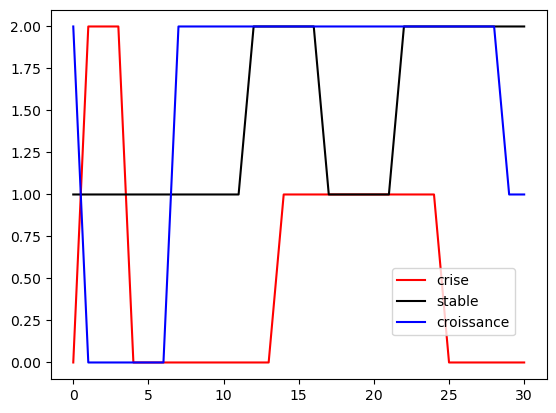

In [890]:
abscisse = np.arange(0, len(etat0[1]), 1)
plt.plot(abscisse, etat0[1], color = 'red', label = "crise")
plt.plot(abscisse, etat1[1], c ='black', label = "stable")
plt.plot(abscisse, etat2[1], c ='blue', label = "croissance")
plt.legend(loc = "lower right", bbox_to_anchor=(0.95, 0.1))


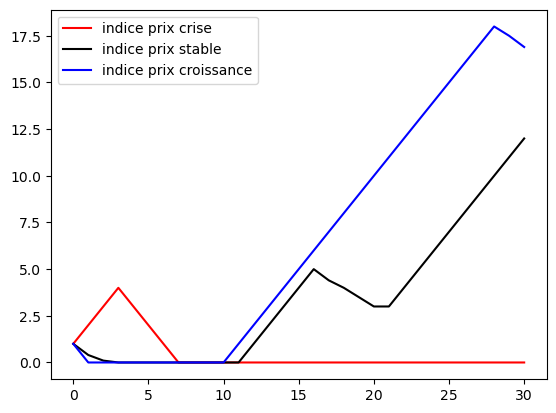

In [891]:
grapheindice= np.arange(0, len(testaleatoire[3]), 1)
plt.plot(grapheindice, etat0[3], color = 'red', label = "indice prix crise")
plt.plot(grapheindice, etat1[3], color = 'black', label = "indice prix stable")
plt.plot(grapheindice, etat2[3], color = 'blue', label = "indice prix croissance")
plt.legend()  

In [598]:
indice0 = 1
population = 100
titres2 = 10
res = [indice0]
matrice1 = [[1/3, 1/3 ,1/3], [1/3, 1/3 ,1/3], [1/3, 1/3 ,1/3]]  #on a choisi que 3 états, on peut en choisir plus. 

vecteurpopulation4 = np.random.normal(0.5, 0.15, population) 
vecteurindices4 = np.array([np.random.uniform() for _ in range(titres2)])

testaleatoire = fonction_cas1(matrice=matrice1, etat= 2, vecteurpopulation = vecteurpopulation4, vecteurindice=vecteurindices4, n=30, epsilon =0.01)


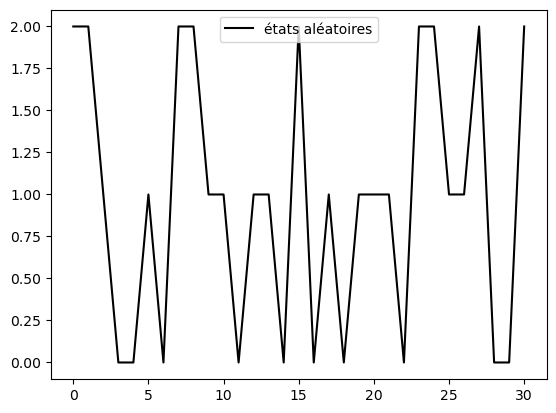

In [556]:
abscisse = np.arange(0, len(testaleatoire[1]), 1)
plt.plot(abscisse, testaleatoire[1], color = 'black', label = "états aléatoires")
plt.legend()

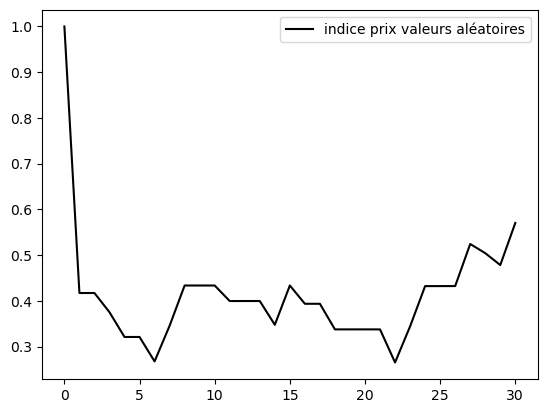

In [557]:
grapheindice= np.arange(0, len(testaleatoire[3]), 1)
plt.plot(grapheindice, testaleatoire[3], color = 'black', label = "indice prix valeurs aléatoires")
plt.legend()   